### Internship Task

#### QUESTION 1

In [57]:
import pandas as pd

df = pd.read_csv('Fraud.csv')
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [59]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [60]:
## To find out outliers, we need to calculate IQR (interquartile range)
## which helps to define the minimum and maximum values to find out outliers

Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 *IQR
upper_bound = Q3 + 1.5 *IQR

outliers = df[(df['amount']< lower_bound) | (df['amount']> upper_bound)]

In [61]:
outliers

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
85,1,TRANSFER,1505626.01,C926859124,0.00,0.0,C665576141,29031.00,5515763.34,0,0
86,1,TRANSFER,554026.99,C1603696865,0.00,0.0,C766572210,579285.56,0.00,0,0
88,1,TRANSFER,761507.39,C412788346,0.00,0.0,C1590550415,1280036.23,19169204.93,0,0
89,1,TRANSFER,1429051.47,C1520267010,0.00,0.0,C1590550415,2041543.62,19169204.93,0,0
93,1,TRANSFER,583848.46,C1839168128,0.00,0.0,C1286084959,667778.00,2107778.11,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362613,743,CASH_OUT,1258818.82,C1436118706,1258818.82,0.0,C1240760502,503464.50,1762283.33,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0


In [62]:
## Z-SCORE
from scipy import  stats

df['z_score'] = stats.zscore(df['amount'])

## define outliers as values are 3 mean deviation
outliers = df[df['z_score'].abs() >3]

In [63]:
outliers

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,z_score
359,1,TRANSFER,2421578.09,C106297322,0.00,0.00,C1590550415,8515645.77,19169204.93,0,0,3.712322
375,1,TRANSFER,2545478.01,C1057507014,0.00,0.00,C1590550415,12394437.40,19169204.93,0,0,3.917503
376,1,TRANSFER,2061082.82,C2007599722,0.00,0.00,C1590550415,14939915.42,19169204.93,0,0,3.115336
1153,1,TRANSFER,3776389.09,C197491520,0.00,0.00,C1883840933,10138670.86,16874643.09,0,0,5.955914
1202,1,TRANSFER,2258388.15,C12139181,0.00,0.00,C1789550256,2784129.27,4619798.56,0,0,3.442077
...,...,...,...,...,...,...,...,...,...,...,...,...
6362584,741,TRANSFER,5674547.89,C992223106,5674547.89,5674547.89,C1366804249,0.00,0.00,1,1,9.099299
6362598,742,TRANSFER,4009058.39,C1044665079,4009058.39,0.00,C750074708,0.00,0.00,1,0,6.341218
6362599,742,CASH_OUT,4009058.39,C1970706589,4009058.39,0.00,C637394241,1229761.96,5238820.34,1,0,6.341218
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,10.153953


### Why do both methods give different values for the outliers?
- In z-score method , it assumes data is normally distributed but usually data is skewed which means in case of fraud detections many small payments and few large ones so, it is not reliable in such case.
- On the other hand, IQR method define two values just like boundaries to define outliers to make data more reliable for data analysis and more accurate prediction model. So, for now We will use IQR method .



In [65]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,z_score
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,-0.281560
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,-0.294767
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,-0.297555
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,-0.297555
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,-0.278532
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,0.264665
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,10.153953
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,10.153953
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,1.109765


In [66]:
df_numeric = df.select_dtypes(include=['number'])
df_numeric.corr()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,z_score
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277,0.022373
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295,1.000000
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835,-0.002762
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776,-0.007861
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513,0.294137
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529,0.459304
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109,0.076688
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000,0.012295
z_score,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295,1.000000


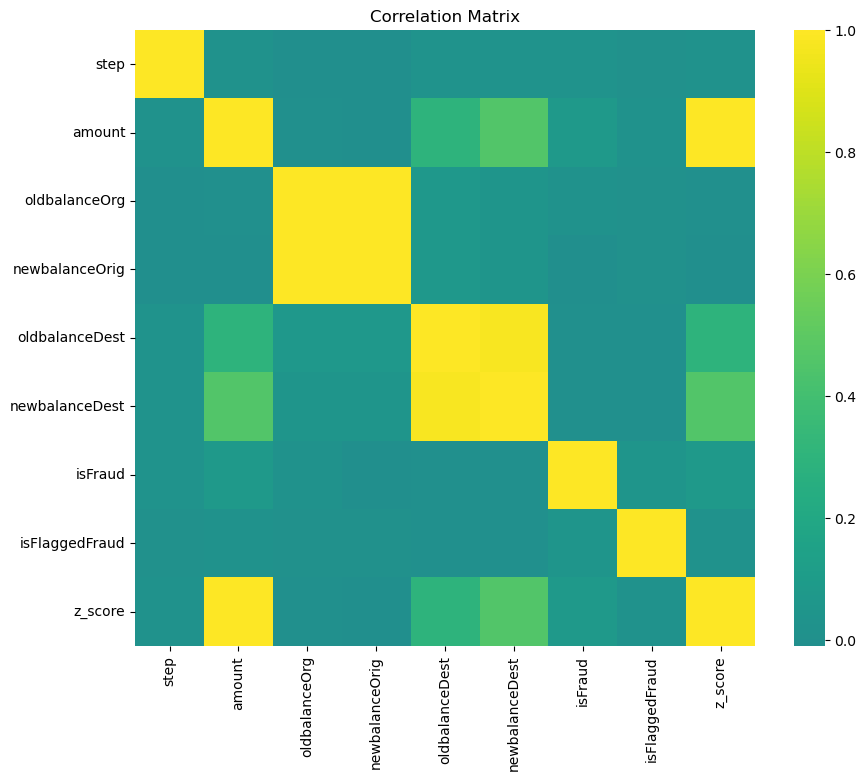

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix =df_numeric .corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="viridis", center=0)
plt.title("Correlation Matrix")
plt.show()

#### QUESTION 2 & 4

#### FRAUD DETECTION MODEL
I am using logistic regression model as it is easy to deploy and give highly accurate predictions. 

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [71]:
x_train, x_test, y_train, y_test = train_test_split(df_numeric.drop('isFraud', axis=1), df_numeric['isFraud'], test_size= 0.33, random_state = 17)

In [72]:
## predictions
clf = LogisticRegression().fit(x_train, y_train)

y_pred = clf.predict(x_test)
print(accuracy_score(y_pred, y_test))

C:\Users\Rashi Bali\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9992017774263989


In [73]:
print(confusion_matrix(y_test, y_pred))


[[2096749     201]
 [   1475    1240]]


In [74]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, 
                     index=["Actual_NonFraud", "Actual_Fraud"], 
                     columns=["Pred_NonFraud", "Pred_Fraud"])
print(cm_df)

                 Pred_NonFraud  Pred_Fraud
Actual_NonFraud        2096749         201
Actual_Fraud              1475        1240


### What the values mean

20,96,749 : TN (True Negative) → Non-fraud correctly predicted as non-fraud.

201: FP (False Positive) → Non-fraud incorrectly predicted as fraud (false alarm).

1475: FN (False Negative) → Fraud incorrectly predicted as non-fraud (missed fraud).

1240: TP (True Positive) → Fraud correctly predicted as fraud.

### QUESTION 3

- step 1 : Data cleaning but this data contains non-null values so there's no need to drop null or fill null values.
- step 2 : By doing correlation we check multicollinearity
- step 3 : trained logistic regression model to predict the fraud customers in the data


I selected variables by first removing those with high missing values, low variance, or strong multicollinearity. Then I used model-based methods to keep features with meaningful predictive power and added business-relevant factors such as transaction  ensuring the final set was both statistically sound and practical for fraud detection.

### QUESTION 5

1. Transaction Amount
2. Location/destination match mismatch
3. Customer Behavior Patterns

   The key factors that predict fraudulent customers include unusually high transaction amounts, a high number of transactions in a short time, mismatches between location or device and the customer’s normal behavior, transactions at unusual hours, purchases from high-risk merchants, and deviations from the customer’s typical spending pattern.


### QUESTION 6 

yes, These factors makes sense such as Key factors that predict fraudulent customers include unusually high or rapid transactions, location or device mismatches, odd transaction times, high-risk merchants, and sudden changes in spending patterns. These factors make sense because they reflect common fraud behaviors, such as testing stolen cards, making quick purchases before detection, and using unfamiliar devices or risky merchants.

### QUESTION 7

When updating its infrastructure, a company should adopt multiple prevention measures to reduce fraud risk. These include strengthening authentication mechanisms (eg: multi-factor authentication, device fingerprinting), encrypting sensitive data, and using real-time fraud monitoring systems. The company should also implement regular security audits, ensure proper access control. Additionally, employee training and customer awareness programs should accompany technical updates, since human error is often exploited in fraud attempts.

### QUESTION 8 

1. Reduction in number and value of fraudulent transactions
2. Decrease in financial losses due to fraud
3. Faster detection and response time to suspicious activity
4. Positive customer feedback on security and trust